<a href="https://colab.research.google.com/github/insafroumy/Prediction-of-Product-Sales/blob/main/prediction_of_product_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction of Product Sales

- Auther: Insaf AlRumi

## Project Overview

## Loading Data




In [173]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [174]:
import numpy as np
import pandas as pd

fname = "/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv"
df_prediction = pd.read_csv(fname)


In [175]:
df_prediction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [176]:
df_prediction.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## Data Cleaning

In [177]:
#1) How many rows and columns?
df_prediction.shape

(8523, 12)

In [178]:
#2) What are the datatypes of each variable?
df_prediction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [179]:
#3) Are there duplicates? If so, drop any duplicates.
duplicated_rows = df_prediction.duplicated()
duplicated_rows.sum()

np.int64(0)

In [180]:
#4) Identify missing values.
null_counts = df_prediction.isna().sum()
null_counts

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [181]:
#5) Address the missing values by using a placeholder value.
df_prediction['Outlet_Size'] = df_prediction['Outlet_Size'].fillna("Missing")
df_prediction['Item_Weight'] = df_prediction['Item_Weight'].fillna(-1)
df_prediction


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Missing,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,Missing,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [182]:
#6) Confirm that there are no missing values after addressing them.
null_counts = df_prediction.isna().sum()
null_counts

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [183]:
#7) Find and fix any inconsistent categories of data (for example: fix cat, Cat, and cats so that they are consistent).
df_prediction['Item_Fat_Content'] = df_prediction['Item_Fat_Content'].replace({'LF': 'Low Fat',
                                                                             'low fat': 'Low Fat',
                                                                             'reg': 'Regular'})
df_prediction['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [184]:
numerical_stats = df_prediction.describe().loc[['min', 'max', 'mean']]

numerical_stats

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
min,-1.000000,0.000000,31.290000,1985.000000,33.290000
max,21.350000,0.328391,266.888400,2009.000000,13086.964800
mean,10.478936,0.066132,140.992782,1997.831867,2181.288914


## Exploratory Data Analysis

In [185]:
#Import libraries
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Histograms (Numerical Distributions)

/tmp/ipykernel_894/1572793052.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');


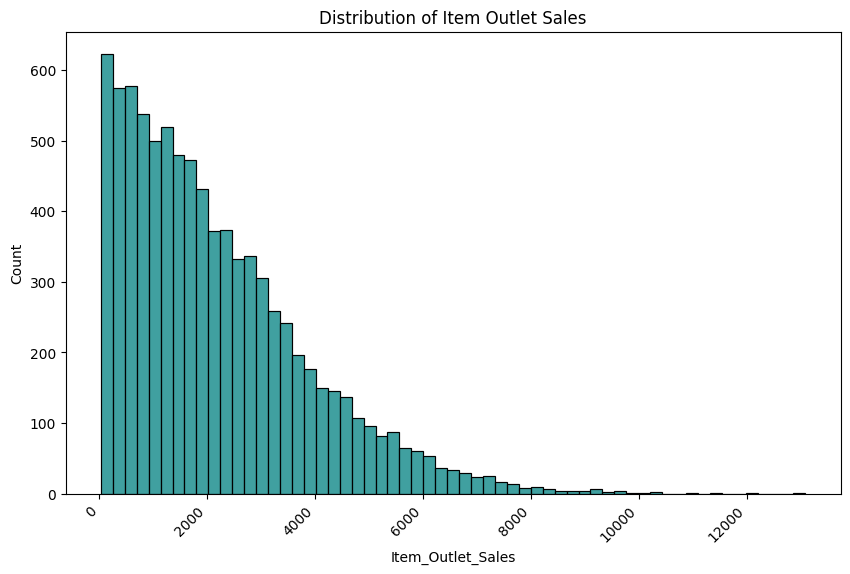

In [186]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=df_prediction, x='Item_Outlet_Sales', ax=ax, color='teal')
ax.set_title('Distribution of Item Outlet Sales')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');

#### Histogram Interpretation
-- Description:

- "This histogram displays the distribution of Item Outlet Sales, showing the frequency of different sales volume ranges across all stores."

-- Insight:

- "The data is right-skewed, indicating that the majority of products have lower sales volumes (between 0 and 4,000), while only a few high-performing items reach sales figures above 8,000."

### 2. Boxplots (Statistical Summaries)

/tmp/ipykernel_894/2491623794.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');


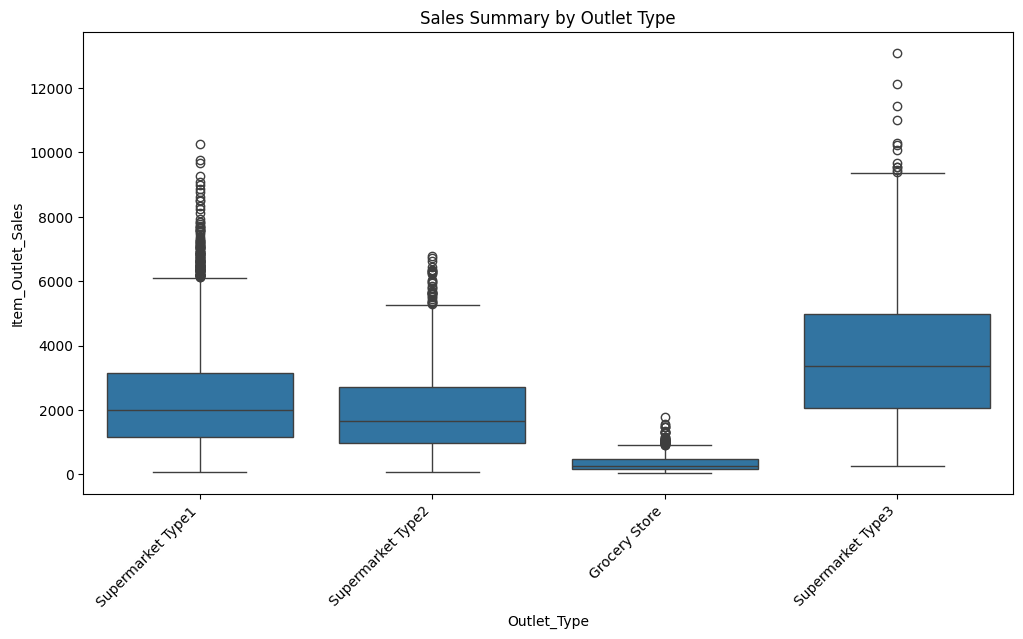

In [187]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_prediction, x='Outlet_Type', y='Item_Outlet_Sales', ax=ax)
ax.set_title('Sales Summary by Outlet Type')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');

### 3. Countplots (Categorical Frequency)

/tmp/ipykernel_894/511248317.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');


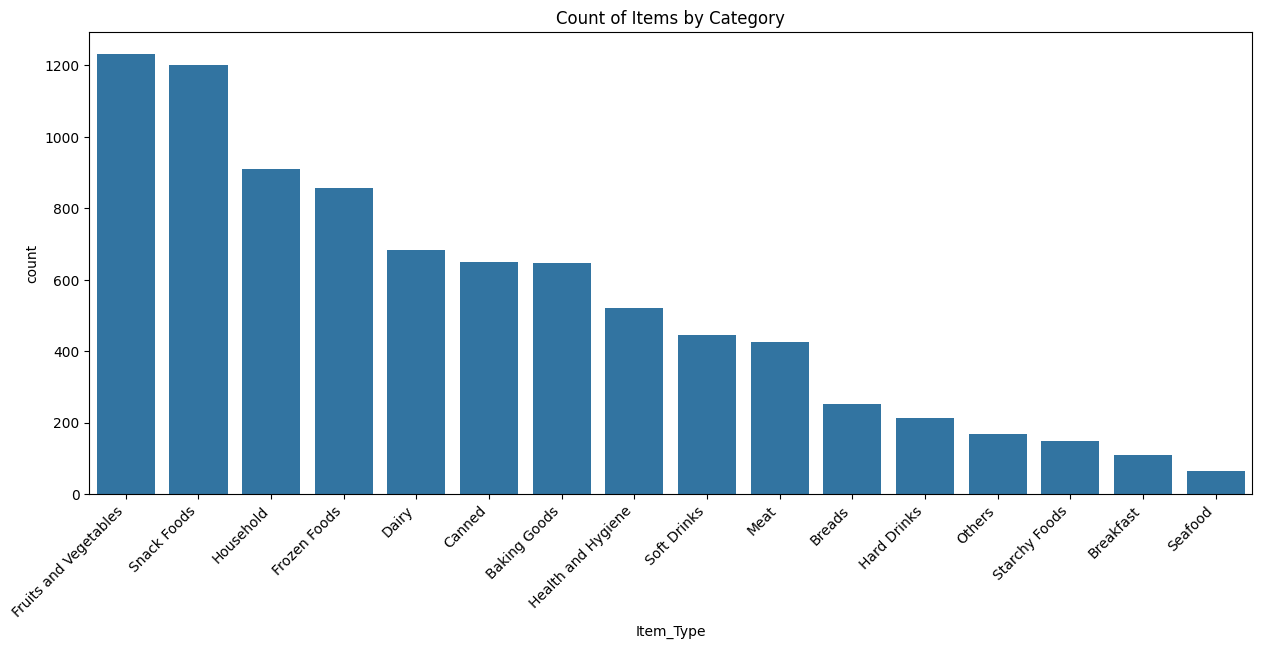

In [188]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.countplot(data=df_prediction, x='Item_Type', ax=ax, order=df_prediction['Item_Type'].value_counts().index)
ax.set_title('Count of Items by Category')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');

### 4. Heatmap (Feature Correlation)

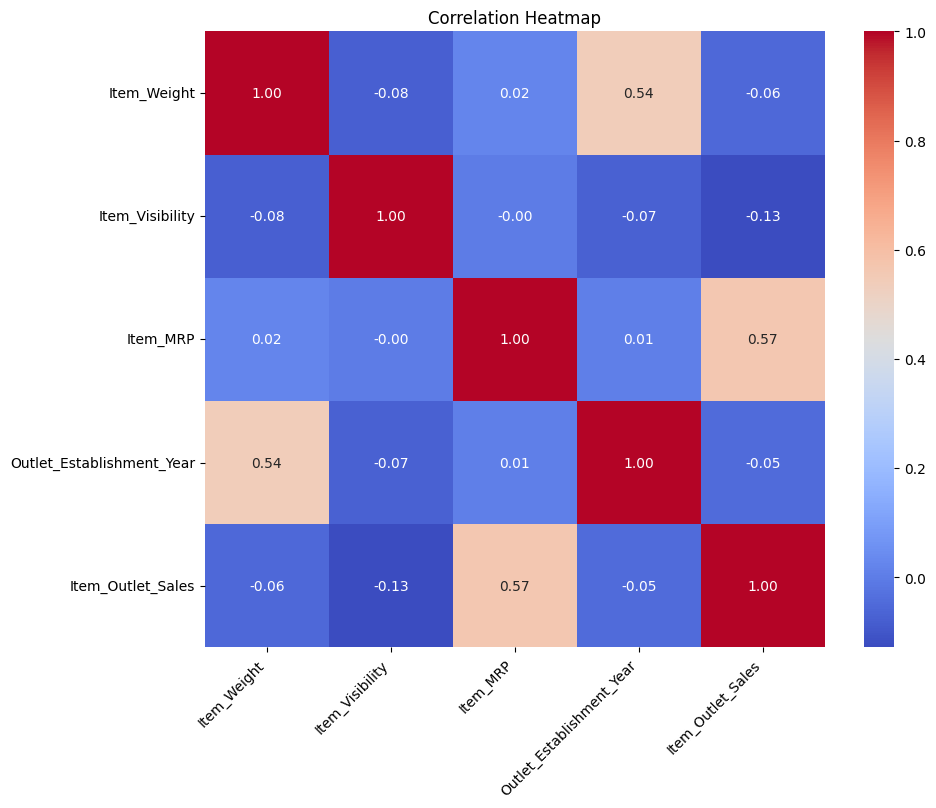

In [189]:
fig, ax = plt.subplots(figsize=(10, 8))
correlation = df_prediction.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
ax.set_title('Correlation Heatmap')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right');

#### Heatmap Interpretation
-- Description:

- "This heatmap visualizes the correlation coefficients between the numerical features of the dataset, helping to identify how different variables like price, weight, and visibility relate to total sales."

-- Insight:

- "The most significant finding is a strong positive correlation (0.57) between Item_MRP (Maximum Retail Price) and Item_Outlet_Sales, suggesting that as the price of an item increases, the total sales revenue generated by that item also tends to rise."

## Feature Inspection

In [190]:
df_prediction.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

In [191]:
def plot_numeric_vs_target(df, x, y='Item_Outlet_Sales', figsize=(6,4), **kwargs): # kwargs for sns.regplot
  # Calculate the correlation
  corr = df[[x,y]].corr().round(2)
  r = corr.loc[x,y]
  # Plot the data
  fig, ax = plt.subplots(figsize=figsize)
  scatter_kws={'ec':'white','linewidths':1,'alpha':0.8}
  sns.regplot(data=df, x=x, y=y, ax=ax, scatter_kws=scatter_kws, **kwargs) # Included the new argument within the sns.regplot function
  ## Add the title with the correlation
  ax.set_title(f"{x} vs. {y} (r = {r})",color= 'white')
   # styling
  fig.patch.set_facecolor('black')
  fig.patch.set_edgecolor('white')
  fig.patch.set_linewidth(2)
  for spine in ax.spines.values():
    spine.set_color('white')
  ax.set_facecolor('black')
  ax.tick_params(colors='white')
  ax.set_xlabel(x ,color='white')
  ax.set_ylabel(y,color='white')

  # Make sure the plot is shown before the print statement
  plt.show()
  return fig, ax


In [192]:
def explore_categorical(df, x, fillna = True, placeholder = 'MISSING',
                        figsize = (6,4), order = None):

  # Make a copy of the dataframe and fillna
   temp_df = df.copy()
  # Before filling nulls, save null value counts and percent for printing
   null_count = temp_df[x].isna().sum()
   null_perc = null_count/len(temp_df)* 100
  # fillna with placeholder
   if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
   fig, ax = plt.subplots(figsize=figsize)
  # Plotting a count plot
   sns.countplot(data=temp_df, x=x, ax=ax, order=order)
  # Rotate Tick Labels for long names
   ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title with the feature name included
   ax.set_title(f"Column: {x}",color ='white')
    # styling
   fig.patch.set_facecolor('black')
   fig.patch.set_edgecolor('white')
   fig.patch.set_linewidth(2)
   for spine in ax.spines.values():
    spine.set_color('white')
   ax.set_facecolor('black')
   ax.tick_params(colors='white')
   ax.set_xlabel(x ,color='white')
   ax.set_ylabel('Count',color='white')


  # Fix layout and show plot (before print statements)
   fig.tight_layout()
   plt.show()

  # Print null value info
   print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
   nunique = temp_df[x].nunique()
   print(f"- Unique Values: {nunique}")
  # First find value counts of feature
   val_counts = temp_df[x].value_counts(dropna=False)
  # Define the most common value
   most_common_val = val_counts.index[0]
  # Define the frequency of the most common value
   freq = val_counts.values[0]
  # Calculate the percentage of the most common value
   perc_most_common = freq / len(temp_df) * 100
  # Print the results
   print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
  # print message if quasi-constant or constant (most common val more than 98% of data)
   if perc_most_common > 98:
     print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
   else:
     print("- Not constant or quasi-constant.")
   return fig, ax


In [193]:
def plot_categorical_vs_target(df, x, y='SalePrice',figsize=(6,4),fillna = True, placeholder = 'MISSING',order = None):
  # Make a copy of the dataframe and fillna
   temp_df = df.copy()
  # fillna with placeholder
   if fillna == True:
     temp_df[x] = temp_df[x].fillna(placeholder)

  # or drop nulls prevent unwanted 'nan' group in stripplot
   else:
    temp_df = temp_df.dropna(subset=[x])
  # Create the figure and subplots
   fig, ax = plt.subplots(figsize=figsize)

    # Barplot
   sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
              linewidth=1, edgecolor='black', errorbar=None)

  # Striplot
   sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                order=order, hue_order=order, legend=False,
                edgecolor='white', linewidth=0.5,
                size=3,zorder=0)
  # Rotate xlabels
   ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',color='white')


  # Add a title
   ax.set_title(f"{x} vs. {y}",color= 'white')
    # styling
   fig.patch.set_facecolor('black')
   fig.patch.set_edgecolor('white')
   fig.patch.set_linewidth(2)
   for spine in ax.spines.values():
    spine.set_color('white')
   ax.set_facecolor('black')
   ax.tick_params(colors='white')
   ax.set_xlabel(x ,color='white')
   ax.set_ylabel('Count',color='white')

   fig.tight_layout()
   return fig, ax

In [194]:
def explore_numeric(df, x, figsize=(6,5) ):
  # Making our figure with gridspec for subplots
   gridspec = {'height_ratios':[0.7,0.3]}
   fig, axes = plt.subplots(nrows=2, figsize=figsize,
                           sharex=True, gridspec_kw=gridspec)
  # Histogram on Top
   sns.histplot(data=df, x=x, ax=axes[0])
  # Boxplot on Bottom
   sns.boxplot(data=df, x=x, ax=axes[1])
  ## Adding a title
   axes[0].set_title(f"Column: {x}",color='white')
  ## Adjusting subplots to best fill Figure
   fig.tight_layout()
   # styling
   fig.patch.set_facecolor('black')
   fig.patch.set_edgecolor('white')
   fig.patch.set_linewidth(2)
   for spine in axes[0].spines.values():
    spine.set_color('white')
   for spine in axes[1].spines.values():
    spine.set_color('white')
   axes[0].set_facecolor('black')
   axes[1].set_facecolor('black')
   axes[0].tick_params(colors='white')
   axes[1].tick_params(colors='white')
   axes[0].set_xlabel(x ,color='white')
   axes[1].set_xlabel(x ,color='white')
   axes[0].set_ylabel('Count',color='white')

  # Ensure plot is shown before message
   plt.show()
  ## Print message with info on the count and % of null values
   null_count = df[x].isna().sum()
   null_perc = null_count/len(df)* 100
   print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
   nunique = df[x].nunique()
   print(f"- Unique Values: {nunique}")


  # Get the most most common value, its count as # and as %
   most_common_val_count = df[x].value_counts(dropna=False).head(1)
   most_common_val = most_common_val_count.index[0]
   freq = most_common_val_count.values[0]
   perc_most_common = freq / len(df) * 100

   print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")

  # print message if quasi-constant or constant (most common val more than 98% of data)
   if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
   else:
    print("- Not constant or quasi-constant.")
   return fig, axes


In [195]:
df_prediction['Item_Weight'] = df_prediction['Item_Weight'].replace('Missing', np.nan)
df_prediction['Outlet_Size'] = df_prediction['Outlet_Size'].replace('Missing', np.nan)

# Item_Weight

- Description: Weight of product

In [196]:
df_prediction['Item_Weight'].dtype

dtype('float64')

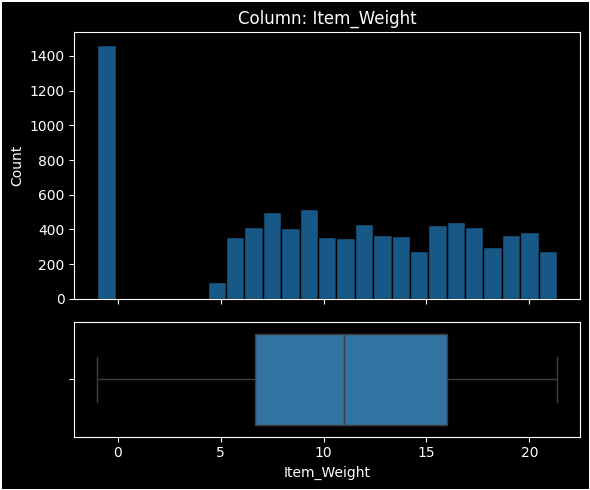

- NaN's Found: 0 (0.0%)
- Unique Values: 416
- Most common value: '-1.0' occurs 1463 times (17.17%)
- Not constant or quasi-constant.


In [147]:
explore_numeric(df_prediction,'Item_Weight');

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - numeric

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 1463 (17.17%)
  - impute with mean.

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - Not applicable (numeric).

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.


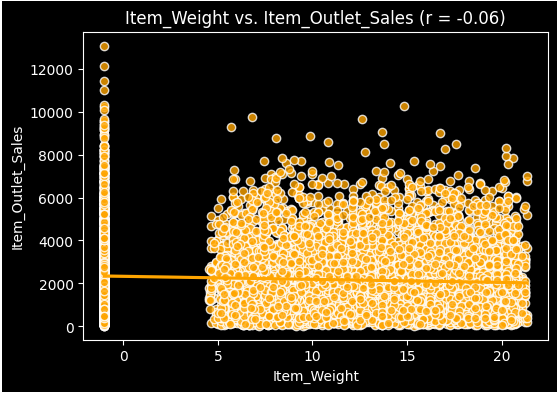

In [148]:
plot_numeric_vs_target(df_prediction,'Item_Weight','Item_Outlet_Sales',figsize=(6,4),color='orange');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes, I assume the highest item weight will have the highest sales.
  - Does this feature appear to be a predictor of the target?
    - No , there is a very weak correlation between them.


# Item_Fat_Content

- Description: Whether the product is low-fat or regular


In [149]:
df_prediction['Item_Fat_Content'].dtype

dtype('O')

/tmp/ipykernel_894/1849275852.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


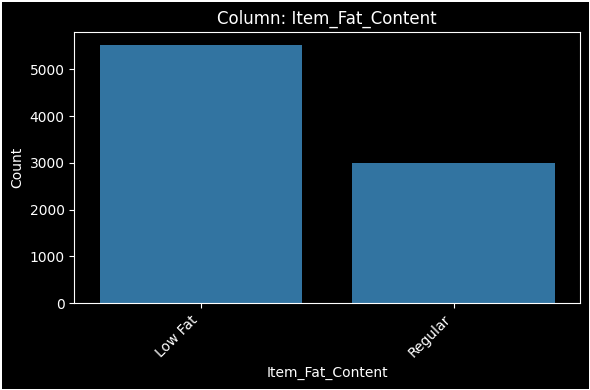

- NaN's Found: 0 (0.0%)
- Unique Values: 2
- Most common value: 'Low Fat' occurs 5517 times (64.73%)
- Not constant or quasi-constant.


In [150]:
explore_categorical(df_prediction,'Item_Fat_Content',order= df_prediction['Item_Fat_Content'].value_counts().index);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - ordinal

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - unigue values(2) very low

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

/tmp/ipykernel_894/3063081188.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',color='white')


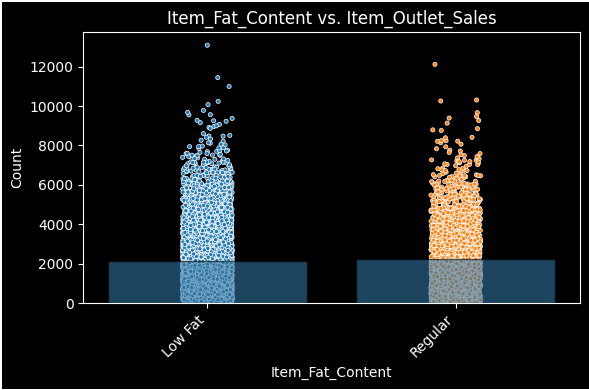

In [151]:
plot_categorical_vs_target(df_prediction,'Item_Fat_Content','Item_Outlet_Sales',figsize=(6,4));

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes, I assume the low fat will have a higher sales.
  - Does this feature appear to be a predictor of the target?
    - No , the sales for low fat and regular are the same or very closer

# Item_Visibility

- Description: The percentage of total display area of all products in a store allocated to the particular product.

In [152]:
df_prediction['Item_Visibility'].dtype

dtype('float64')

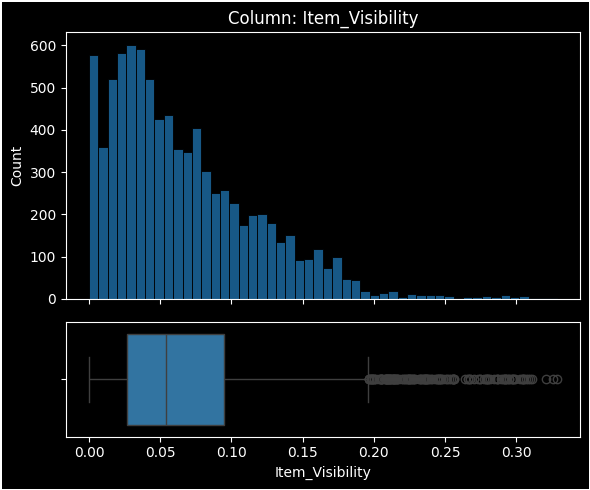

- NaN's Found: 0 (0.0%)
- Unique Values: 7880
- Most common value: '0.0' occurs 526 times (6.17%)
- Not constant or quasi-constant.


In [153]:
explore_numeric(df_prediction,'Item_Visibility');

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - numeric

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - Not applicable (numeric).

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

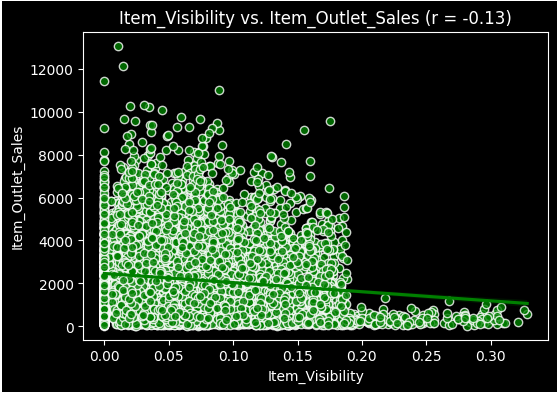

In [154]:
plot_numeric_vs_target(df_prediction,'Item_Visibility','Item_Outlet_Sales',figsize=(6,4),color='green');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Maybe
  - Does this feature appear to be a predictor of the target?
    - No , there is a very weak negative correlation between them.


# Item_type

- Description: The category to which the product belongs

In [155]:
df_prediction['Item_Type'].dtype

dtype('O')

/tmp/ipykernel_894/1849275852.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


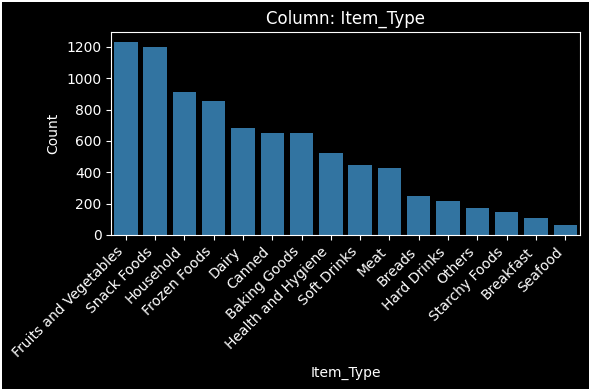

- NaN's Found: 0 (0.0%)
- Unique Values: 16
- Most common value: 'Fruits and Vegetables' occurs 1232 times (14.46%)
- Not constant or quasi-constant.


In [156]:
explore_categorical(df_prediction,'Item_Type',order= df_prediction['Item_Type'].value_counts().index);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - categorical

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - high as the unigue values=16

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

/tmp/ipykernel_894/3063081188.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',color='white')


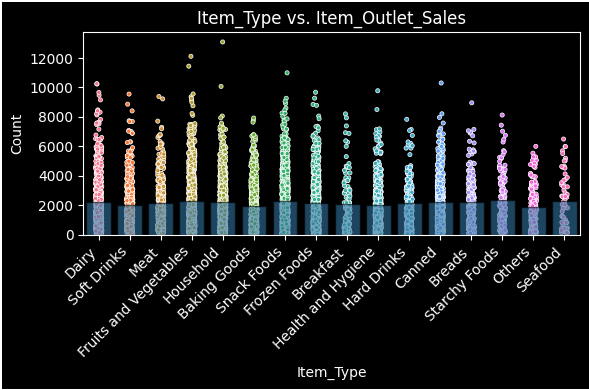

In [157]:
plot_categorical_vs_target(df_prediction,'Item_Type','Item_Outlet_Sales',figsize=(6,4));

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - No
  - Does this feature appear to be a predictor of the target?
    - No , All categories have sales around 2000


# Item_MRP

- Discription: Maximum Retail Price (list price) of the product


In [158]:
df_prediction['Item_MRP'].dtype

dtype('float64')

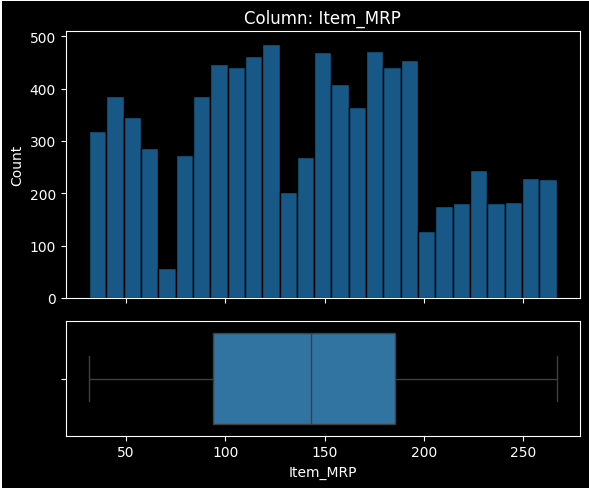

- NaN's Found: 0 (0.0%)
- Unique Values: 5938
- Most common value: '172.0422' occurs 7 times (0.08%)
- Not constant or quasi-constant.


In [159]:
explore_numeric(df_prediction,'Item_MRP');

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - numeric

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - Not applicable (numeric).

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

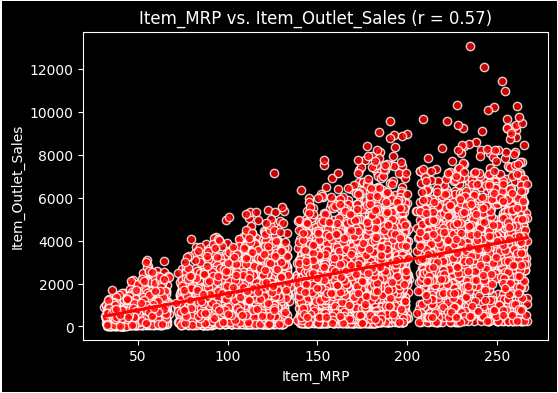

In [160]:
plot_numeric_vs_target(df_prediction,'Item_MRP','Item_Outlet_Sales',figsize=(6,4),color='red');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Maybe
  - Does this feature appear to be a predictor of the target?
    - Yes, there is a moderate positive correlation between them


# Outlet_identifier

- Discription: Store ID

In [161]:
df_prediction['Item_Identifier'].dtype

dtype('O')

/tmp/ipykernel_894/1849275852.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


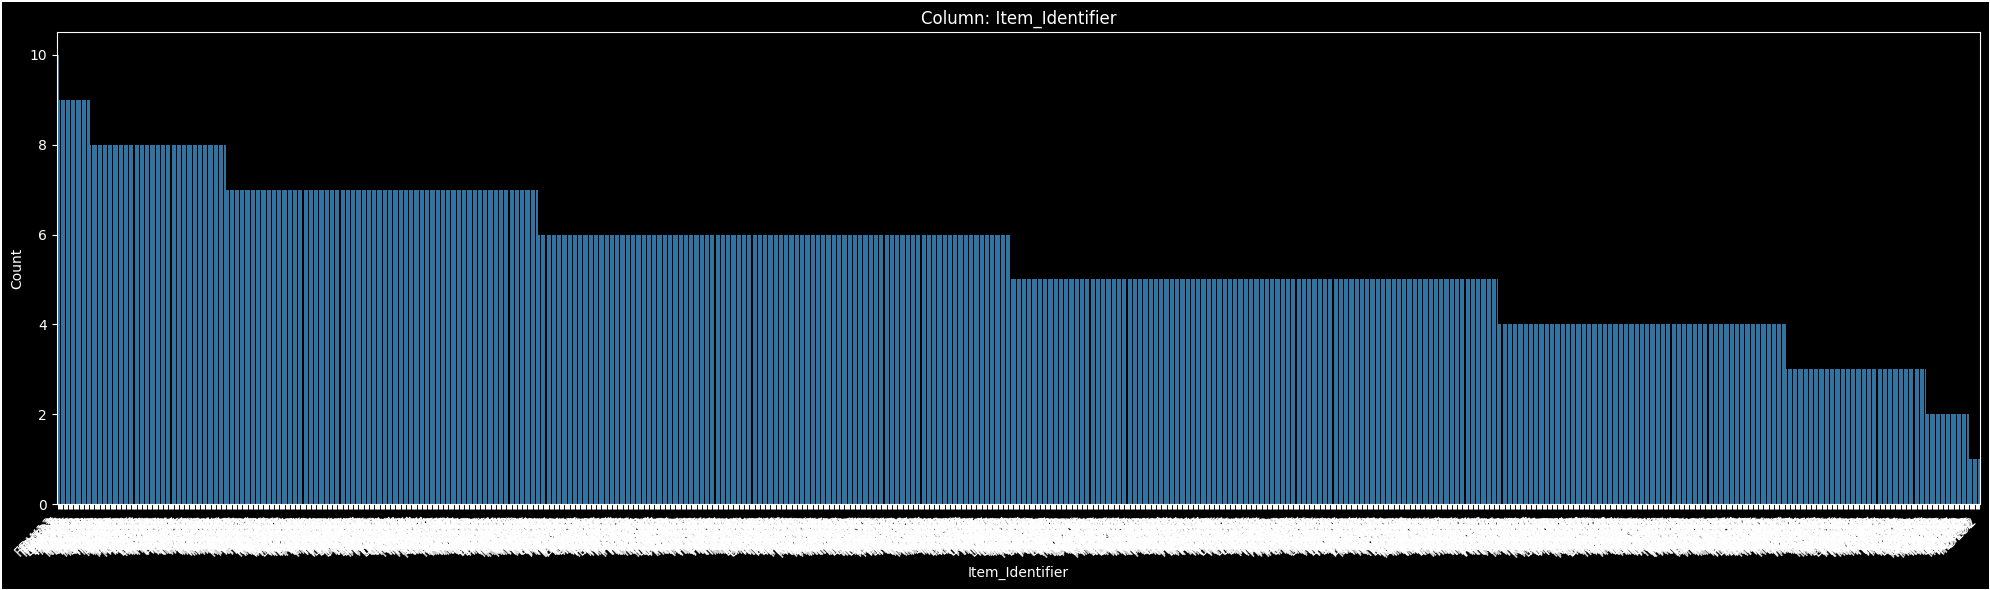

- NaN's Found: 0 (0.0%)
- Unique Values: 1559
- Most common value: 'FDW13' occurs 10 times (0.12%)
- Not constant or quasi-constant.


In [162]:
explore_categorical(df_prediction,'Item_Identifier',order= df_prediction['Item_Identifier'].value_counts().index,figsize=(20,6));

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - categorical

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - very high

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  - Maybe

/tmp/ipykernel_894/3063081188.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',color='white')


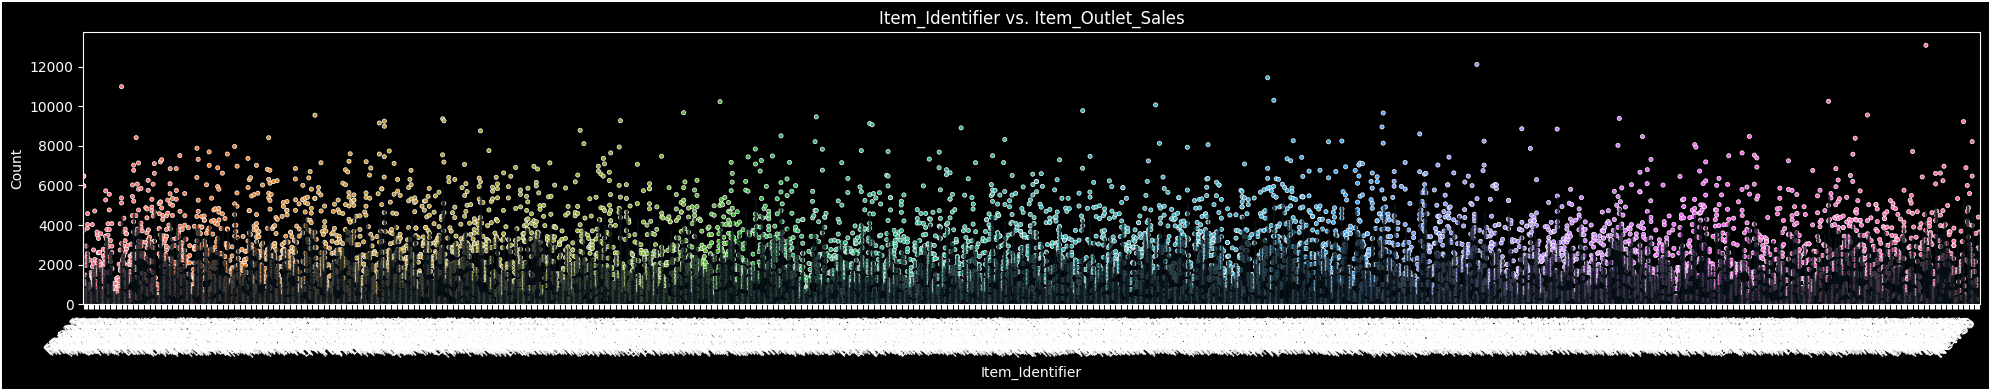

In [163]:
plot_categorical_vs_target(df_prediction,'Item_Identifier','Item_Outlet_Sales',figsize=(20,4));

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - No
  - Does this feature appear to be a predictor of the target?
    - No

# Outlet_Establishment_Year

- Discription: Outlet_Establishment_Year

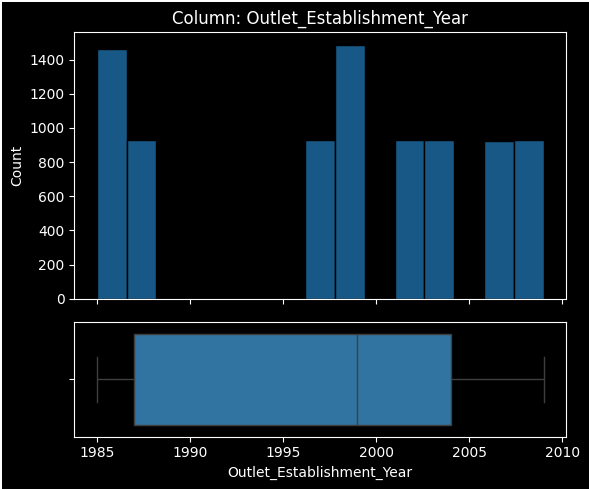

- NaN's Found: 0 (0.0%)
- Unique Values: 9
- Most common value: '1985' occurs 1463 times (17.17%)
- Not constant or quasi-constant.


In [164]:
explore_numeric(df_prediction,'Outlet_Establishment_Year');

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - numeric

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - Not applicable (numeric).

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  - Maybe.

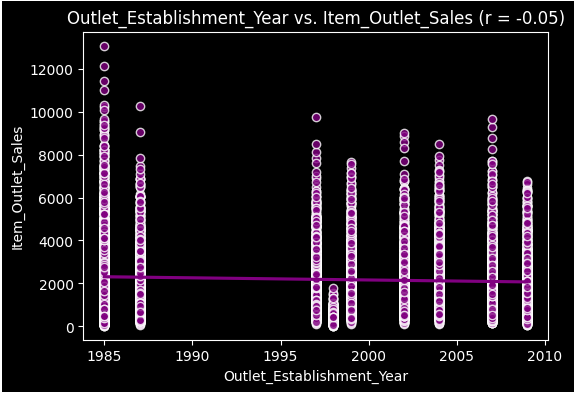

In [165]:
plot_numeric_vs_target(df_prediction,'Outlet_Establishment_Year','Item_Outlet_Sales',figsize=(6,4),color='purple');

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - No
  - Does this feature appear to be a predictor of the target?
    - No , there is a very weak negative correlation between them.


# Outlet_Size

- Discription: The size of the store in terms of ground area covered


/tmp/ipykernel_894/1849275852.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


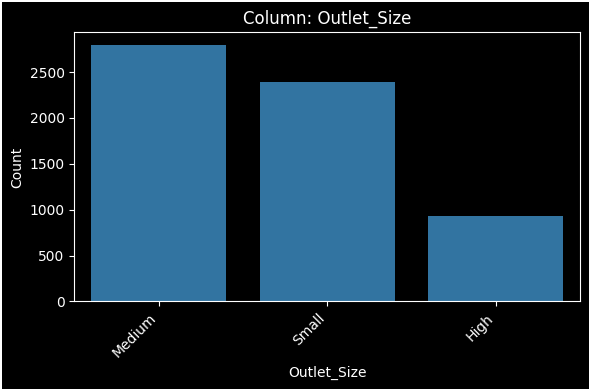

- NaN's Found: 2410 (28.28%)
- Unique Values: 4
- Most common value: 'Medium' occurs 2793 times (32.77%)
- Not constant or quasi-constant.


In [166]:
explore_categorical(df_prediction,'Outlet_Size',order= df_prediction['Outlet_Size'].value_counts().index);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - ordinal

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 2410 (28.28%)
  - impute with 'missing.

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - low.

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  - Maybe.

/tmp/ipykernel_894/3063081188.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',color='white')


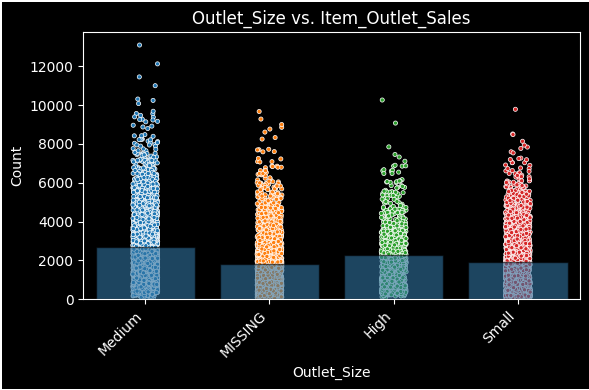

In [167]:
plot_categorical_vs_target(df_prediction,'Outlet_Size','Item_Outlet_Sales',figsize=(6,4));

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Maybe.
  - Does this feature appear to be a predictor of the target?
    - Yes, the medium size has the highest sales


# Outlet_Location_Type

- Discription: The type of area in which the store is located


/tmp/ipykernel_894/1849275852.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


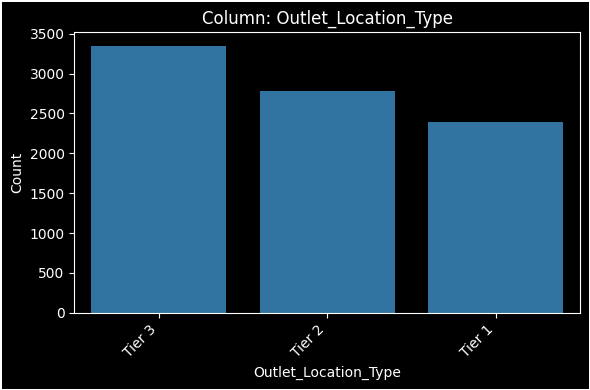

- NaN's Found: 0 (0.0%)
- Unique Values: 3
- Most common value: 'Tier 3' occurs 3350 times (39.31%)
- Not constant or quasi-constant.


In [168]:
explore_categorical(df_prediction,'Outlet_Location_Type',order= df_prediction['Outlet_Location_Type'].value_counts().index);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - Categorical

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - Very low

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  - Maybe.

/tmp/ipykernel_894/3063081188.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',color='white')


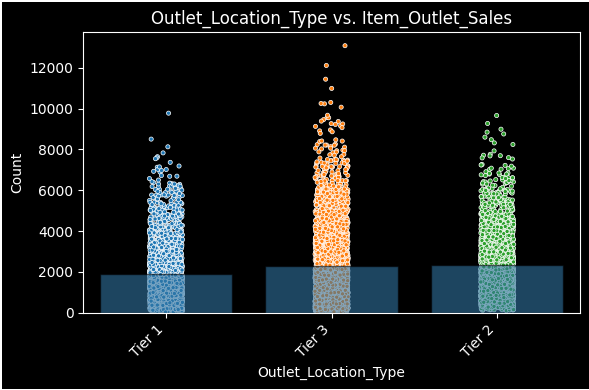

In [169]:
plot_categorical_vs_target(df_prediction,'Outlet_Location_Type','Item_Outlet_Sales',figsize=(6,4));

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - No.
  - Does this feature appear to be a predictor of the target?
    - No , they all have sales around 2000.



# Outlet_Type

- Discription: Whether the outlet is a grocery store or some sort of supermarket

/tmp/ipykernel_894/1849275852.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


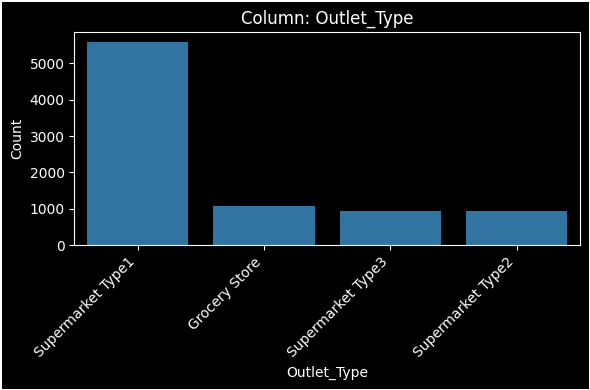

- NaN's Found: 0 (0.0%)
- Unique Values: 4
- Most common value: 'Supermarket Type1' occurs 5577 times (65.43%)
- Not constant or quasi-constant.


In [170]:
explore_categorical(df_prediction,'Outlet_Type',order= df_prediction['Outlet_Type'].value_counts().index);

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - categorical

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0

3. Is the feature constant or quasi-constant?
  - No.

4. What is the cardinality? Is it high?
  - low.

5. Would we know this BEFORE the target is determined?
  - Yes.

6. Is there a business case/understanding reason to exclude based on our business case?
  - No.

/tmp/ipykernel_894/3063081188.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',color='white')


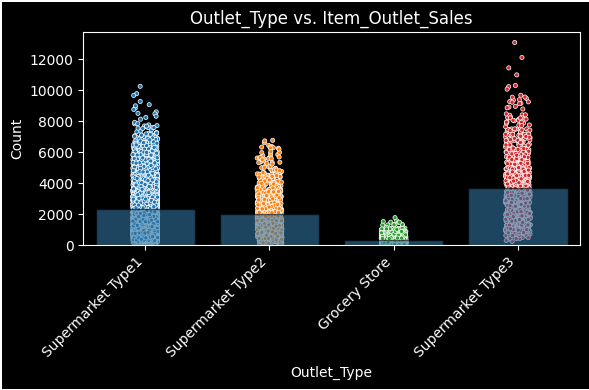

In [171]:
plot_categorical_vs_target(df_prediction,'Outlet_Type','Item_Outlet_Sales',figsize=(6,4));

- Feature vs. Target Observations:
  - Based on your business understanding, would you expect this feature to be a predictor of the target?
    - Yes, I assume the biggest supermarket will have a higher sales.
  - Does this feature appear to be a predictor of the target?
    - Yes, supermarket type3 has the highest sales.

#Item_Outlet_Sales

- Discription: Sales of the product in the particular store. This is the target variable to be predicted

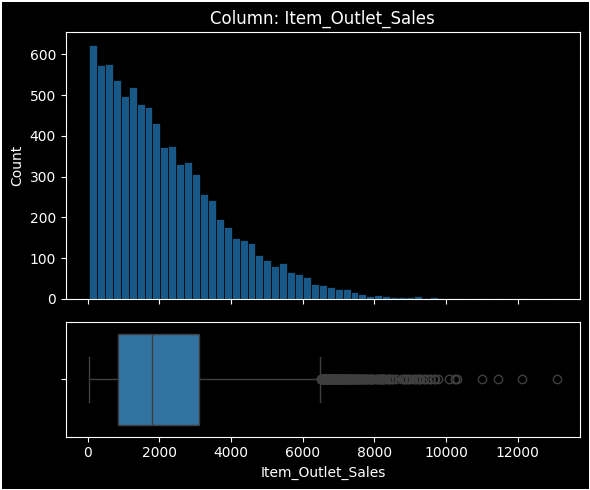

- NaN's Found: 0 (0.0%)
- Unique Values: 3493
- Most common value: '958.752' occurs 17 times (0.2%)
- Not constant or quasi-constant.


In [172]:
explore_numeric(df_prediction,'Item_Outlet_Sales');

**Feature Observations**

1. What type of feature is it? (Categorical (nominal), ordinal, numeric)
  - numeric (our target)

2. How many null values? What percentage? What would you do with the null values (drop the rows? drop the column? impute? if impute, with what?)
  - 0

3. Is the feature constant or quasi-constant?
  - It is not a feature.

4. What is the cardinality? Is it high?
  - Not applicable (numeric).

5. Would we know this BEFORE the target is determined?
  - No, it is the target.

6. Is there a business case/understanding reason to exclude based on our business case?
  - Yes, it is the target.